In [1]:
data_dir = r"C:\Tutorial\Visuara\Computer vision from Scratch\flowers"

In [2]:
#!C:\PYTHON_ENV\env_object_detection\Scripts\python.exe -m pip install torchsummary

In [3]:
# !pip install torchsummary

# !pip install torchinfo

In [4]:
import sys
print(sys.executable)

C:\PYTHON_ENV\env_object_detection\Scripts\python.exe


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torchvision import models

from torchsummary import summary

import wandb
import os

In [6]:
# =======================
# STEP 0: Initialize wandb
# =======================
wandb.init(project="Inceptionv1-flowers", config={
    "epochs": 20,
    "batch_size": 16,
    "learning_rate": 0.001,
    "architecture": "GoogleNet(InceptionV1)",
    "pretrained": True,
    "input_size": 128
})

# Shortcut to config values
config = wandb.config

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\sangr\_netrc.
wandb: Currently logged in as: sangram01 (sangram01-srm-institute-of-science-and-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [7]:
# =======================
# STEP 1: Data Preparation
# =======================

# Transforms for training and validation
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),       # Flipping if size is not 224x224
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

train_dir = r"C:\Tutorial\Visuara\Computer vision from Scratch\flowers/train"
val_dir = r"C:\Tutorial\Visuara\Computer vision from Scratch\flowers/val"

train_dataset = datasets.ImageFolder(root=train_dir, transform=data_transforms['train'])
val_dataset = datasets.ImageFolder(root=val_dir, transform=data_transforms['val'])

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size)

In [8]:
# ===========================
# STEP 2: Load Pretrained Model
# ===========================

from torchvision.models import GoogLeNet_Weights

# Load Pretrained GoogLeNet (Inception V1)
model = models.googlenet(weights = GoogLeNet_Weights.DEFAULT)

#Replace the final FC layer to match 5 flower classes
model.fc = nn.Linear(model.fc.in_features, 5)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False


# Only unfreeze the final classifier layer
for param in model.fc.parameters():
    param.requires_grad = True

# Move model to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

# Watch the model's weights and gradients
wandb.watch(model, log="all", log_freq=10)

cuda


In [9]:
# ===================
# STEP 3: Loss & Optimizer
# ===================

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

In [10]:
def train_model(model, criterion, optimizer, train_loader, val_loader, epochs=10):
    for epoch in range(epochs):
        model.train()
        train_correct = 0
        train_total = 0
        running_loss = 0.0

        print(f"\nEpoch {epoch + 1}/{epochs}")
        print("-" * 30)

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            batch_correct = (preds == labels).sum().item()
            train_correct += batch_correct
            train_total += labels.size(0)

            # Print every 10 batches
            if (i + 1) % 10 == 0:
                batch_acc = batch_correct / labels.size(0)
                print(f"[Batch {i+1}/{len(train_loader)}] Loss: {loss.item():.4f}, Batch Acc: {batch_acc:.4f}")

        train_acc = train_correct / train_total
        wandb.log({"epoch": epoch + 1, "train_loss": running_loss, "train_accuracy": train_acc})
        print(f"Epoch {epoch+1} Summary - Loss: {running_loss:.4f}, Train Accuracy: {train_acc:.4f}")

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        val_acc = val_correct / val_total
        wandb.log({"epoch": epoch + 1, "val_accuracy": val_acc})
        print(f"Validation Accuracy: {val_acc:.4f}")


In [11]:
# ===================
# Train the model
# ===================
train_model(model, criterion, optimizer, train_loader, 
            val_loader, epochs=config.epochs)


Epoch 1/20
------------------------------
[Batch 10/251] Loss: 1.3787, Batch Acc: 0.5625
[Batch 20/251] Loss: 1.3456, Batch Acc: 0.5000
[Batch 30/251] Loss: 1.2611, Batch Acc: 0.4375
[Batch 40/251] Loss: 1.1477, Batch Acc: 0.7500
[Batch 50/251] Loss: 1.1479, Batch Acc: 0.5625
[Batch 60/251] Loss: 1.1974, Batch Acc: 0.4375
[Batch 70/251] Loss: 0.9775, Batch Acc: 0.6875
[Batch 80/251] Loss: 1.0885, Batch Acc: 0.6250
[Batch 90/251] Loss: 0.6571, Batch Acc: 0.9375
[Batch 100/251] Loss: 1.2351, Batch Acc: 0.5000
[Batch 110/251] Loss: 1.1247, Batch Acc: 0.5625
[Batch 120/251] Loss: 0.5992, Batch Acc: 0.9375
[Batch 130/251] Loss: 1.0523, Batch Acc: 0.6250
[Batch 140/251] Loss: 0.6718, Batch Acc: 0.7500
[Batch 150/251] Loss: 0.8886, Batch Acc: 0.6875
[Batch 160/251] Loss: 0.6844, Batch Acc: 0.8125
[Batch 170/251] Loss: 0.6055, Batch Acc: 0.8125
[Batch 180/251] Loss: 0.6047, Batch Acc: 0.8125
[Batch 190/251] Loss: 0.5718, Batch Acc: 0.7500
[Batch 200/251] Loss: 0.5799, Batch Acc: 0.8750
[Batch

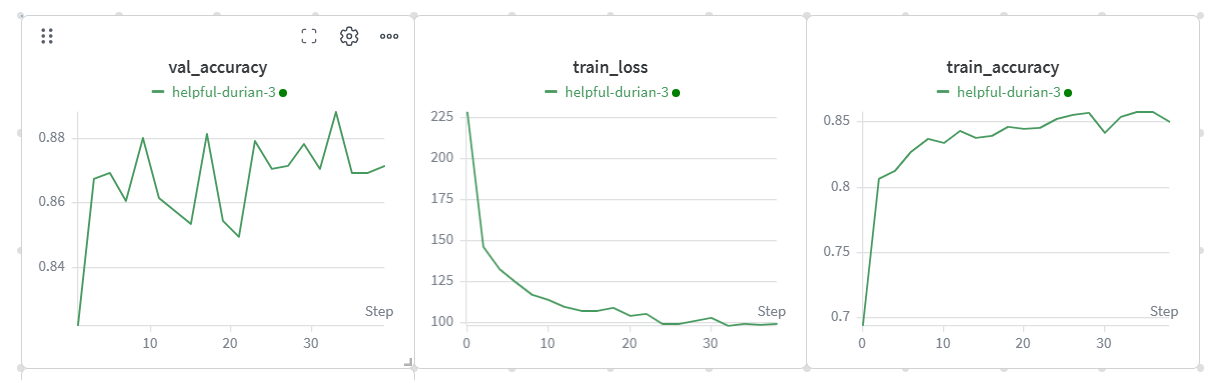